# Laser Cavity Round-Trip Time, Derived From Retarded Time -- Then Mapped to an RLC Circuit

The laser-cavity round-trip time $T_{rt}=2nL/c$ and resonance condition
$f_q=qc/(2nL)$ are usually just STATED. This notebook derives them instead,
starting from the 1D wave equation's general retarded-time solution
$\psi(x,t)=f(t-x/v)$ (verified with SymPy for an arbitrary function $f$,
not a specific waveform), through Maxwell's retarded potentials, to the
cavity round trip as retarded time applied twice. It then maps the
resulting $Q$/finesse/linewidth onto an RLC circuit -- verified by actually
integrating the free RLC ODE -- and the laser threshold condition onto
"net resistance = 0." Engine: `dgs/laser_cavity_rlc_analog.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from dgs import laser_cavity_rlc_analog as lca

sp.init_printing(use_latex='mathjax')
print('Setup complete.')


Setup complete.


## 1. Retarded Time, Derived Step by Step

**Step 1 -- the wave equation.** Any EM field component in a source-free
region (or, in a waveguide/cavity, along the propagation axis) satisfies
the 1D wave equation
$$\frac{\partial^2\psi}{\partial t^2}=v^2\frac{\partial^2\psi}{\partial x^2},
\qquad v=\frac{c}{n}.$$

**Step 2 -- the general retarded-time solution.** ANY function of the
single combined variable $u=t-x/v$ solves this equation -- physically,
$\psi(x,t)=f(t-x/v)$ describes a disturbance that looks, at position $x$
and time $t$, exactly like what happened at $x=0$ at the EARLIER
("retarded") time $t_{ret}=t-x/v$: the disturbance took time $x/v$ to
propagate that far. This is verified symbolically below for a fully
generic $f$, not one specific waveform.

**Step 3 -- Maxwell's retarded potentials (Griffiths ch. 10).** For a real
3D source $\rho(\mathbf r',t)$, $\mathbf J(\mathbf r',t)$, the SAME idea
generalizes to
$$V(\mathbf r,t)=\frac{1}{4\pi\varepsilon_0}\int
\frac{\rho(\mathbf r',t_{ret})}{|\mathbf r-\mathbf r'|}\,d^3r',
\qquad t_{ret}=t-\frac{|\mathbf r-\mathbf r'|}{c}:$$
the potential HERE, NOW depends on the source's state THERE, EARLIER by
exactly the light-travel time between them -- never on the source's
present (unobservable-in-time) state.

**Step 4 -- one cavity bounce is one retarded-time evaluation.** A field
launched from mirror 1 at $t=0$ arrives at mirror 2 (distance $L$ away, in
a medium of index $n$, so $v=c/n$) at the time that makes ITS retarded
time equal zero: $t-\frac{L}{c/n}=0\Rightarrow t=\frac{nL}{c}$ -- one
single-pass transit time. Reflecting and returning to mirror 1 applies the
SAME retarded-time relation a second time, giving the round-trip time
$$T_{rt}=2\times\frac{nL}{c}=\frac{2nL}{c}.$$

**Step 5 -- resonance from phase closure.** A steady-state cavity mode
requires the field to return to itself (same phase, up to $2\pi$) after
one round trip: $\omega T_{rt}=2\pi q$ for integer $q$. Solving for the
allowed frequencies:
$$f_q=\frac{q}{T_{rt}}=\frac{qc}{2nL}\quad\text{and the SPACING between
adjacent modes is the free spectral range}\quad
\mathrm{FSR}=f_{q+1}-f_q=\frac{c}{2nL}=\frac{1}{T_{rt}}.$$


In [2]:
x, t, v_sym, L_sym, n_sym, c_sym = sp.symbols('x t v L n c', positive=True)
f = sp.Function('f')

# Step 2, verified: psi(x,t) = f(t - x/v) solves the 1D wave equation for
# an ARBITRARY f -- not assumed, checked by direct symbolic substitution
psi = f(t - x/v_sym)
wave_eq_residual = sp.simplify(sp.diff(psi, t, 2) - v_sym**2 * sp.diff(psi, x, 2))
print('d^2(psi)/dt^2 - v^2 * d^2(psi)/dx^2 =', wave_eq_residual, '  (0 for ANY f -- verified, not assumed)')


d^2(psi)/dt^2 - v^2 * d^2(psi)/dx^2 = 0   (0 for ANY f -- verified, not assumed)


In [3]:
# Step 4/5, verified against the module's own functions: T_rt = 2nL/c,
# FSR = c/(2nL), derived above from retarded-time closure
T_rt_derived = 2*n_sym*L_sym/c_sym
FSR_derived = c_sym/(2*n_sym*L_sym)
print('T_rt (derived) =', T_rt_derived)
print('FSR (derived)  =', FSR_derived)
print('T_rt * FSR =', sp.simplify(T_rt_derived * FSR_derived), '  (must be exactly 1: FSR = 1/T_rt)')

L_val, n_val = 0.30, 1.0
T_rt_numeric = lca.cavity_round_trip_time(L_val, n_val)
FSR_numeric = lca.cavity_free_spectral_range(L_val, n_val)
T_rt_formula = float(T_rt_derived.subs({n_sym: n_val, L_sym: L_val, c_sym: lca.C_LIGHT}))
FSR_formula = float(FSR_derived.subs({n_sym: n_val, L_sym: L_val, c_sym: lca.C_LIGHT}))
print(f'\nT_rt: module={T_rt_numeric:.6e} s   derived formula={T_rt_formula:.6e} s   match: {abs(T_rt_numeric-T_rt_formula)<1e-15}')
print(f'FSR:  module={FSR_numeric:.6e} Hz  derived formula={FSR_formula:.6e} Hz  match: {abs(FSR_numeric-FSR_formula)<1e-6}')


T_rt (derived) = 2*L*n/c
FSR (derived)  = c/(2*L*n)
T_rt * FSR = 1   (must be exactly 1: FSR = 1/T_rt)

T_rt: module=2.001385e-09 s   derived formula=2.001385e-09 s   match: True
FSR:  module=4.996541e+08 Hz  derived formula=4.996541e+08 Hz  match: True


## 2. Passive Cavity: Photon Lifetime, Q, and Two Linewidth Formulas

With loss (mirror transmission, internal absorption), the round-trip
picture from section 1 gains an amplitude decay on top of the phase
closure: each round trip survives a POWER fraction
$R_{rt}=R_1R_2e^{-2\alpha L}$, giving an exponential energy decay with
time constant $\tau_c=-T_{rt}/\ln(R_{rt})$ and quality factor
$Q=2\pi f_0\tau_c$. Two DIFFERENT textbook formulas for the resulting
linewidth are compared here rather than assumed equivalent.


In [4]:
L, R1, R2, alpha, n = 0.30, 1.0, 0.98, 0.0, 1.0
f0 = lca.C_LIGHT / 633e-9   # 633 nm HeNe-style cavity

tau_c = lca.cavity_photon_lifetime(L, R1, R2, n, alpha)
Q = lca.cavity_Q_factor(f0, tau_c)
print(f'photon lifetime tau_c = {tau_c*1e9:.2f} ns,  Q = {Q:.3e}')

check = lca.verify_linewidth_formulas_agree(L, R1, R2, f0, n, alpha)
print(f"linewidth (Q-based, EXACT):        {check['linewidth_from_Q_Hz']/1e6:.4f} MHz")
print(f"linewidth (finesse-based, F={check['finesse']:.1f}, APPROX): {check['linewidth_from_finesse_Hz']/1e6:.4f} MHz")
print(f"relative difference: {check['relative_difference']:.2e}  (agree within 1%: {check['agree_within_rtol']})")

check_lowF = lca.verify_linewidth_formulas_agree(L, 0.5, 0.5, f0, n, alpha)
print(f"\nLow-finesse cavity (R1=R2=0.5, F={check_lowF['finesse']:.2f}): "
      f"relative difference = {check_lowF['relative_difference']:.2%}  "
      f"(agree within 1%: {check_lowF['agree_within_rtol']})")


photon lifetime tau_c = 99.07 ns,  Q = 2.948e+08
linewidth (Q-based, EXACT):        1.6066 MHz
linewidth (finesse-based, F=311.0, APPROX): 1.6066 MHz
relative difference: 4.25e-06  (agree within 1%: True)

Low-finesse cavity (R1=R2=0.5, F=4.44): relative difference = 1.97%  (agree within 1%: False)


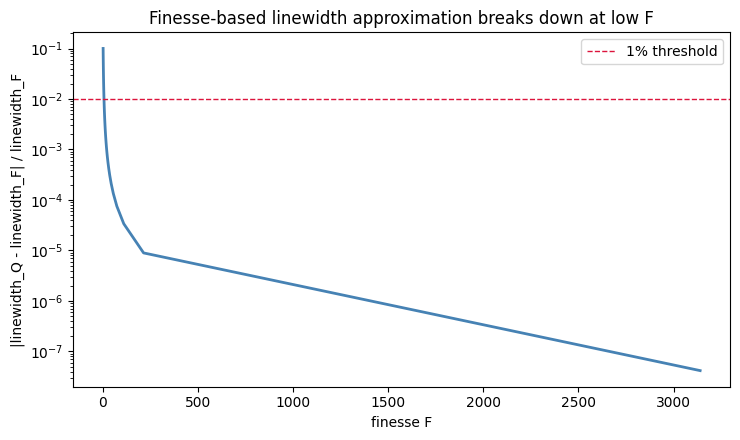

In [5]:
# visualize: linewidth agreement vs finesse, sweeping mirror reflectivity
R_sweep = np.linspace(0.2, 0.999, 60)
rel_diffs, finesses = [], []
for R in R_sweep:
    c = lca.verify_linewidth_formulas_agree(L, R, R, f0, n, alpha)
    rel_diffs.append(c['relative_difference'])
    finesses.append(c['finesse'])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.semilogy(finesses, rel_diffs, color='steelblue', lw=2)
ax.axhline(0.01, color='crimson', ls='--', lw=1, label='1% threshold')
ax.set_xlabel('finesse F'); ax.set_ylabel('|linewidth_Q - linewidth_F| / linewidth_F')
ax.set_title('Finesse-based linewidth approximation breaks down at low F')
ax.legend()
plt.tight_layout()
plt.savefig('laser_rlc_linewidth_approx_breakdown.png', dpi=100, bbox_inches='tight')
plt.show()


## 3. The RLC Electrical Analog -- Verified by Real ODE Simulation

Same $\omega_0$, same $Q$: a series RLC circuit with
$L=QR/\omega_0$, $C=1/(\omega_0^2L)$ (fixing $R$=50$\,\Omega$, the
standard EE characteristic impedance) reproduces the cavity's decay
behavior EXACTLY -- $\tau_{energy}=L/R$ plays the same role $\tau_c$
does optically. Checked here by literally integrating the free RLC ODE
$L\ddot q+R\dot q+q/C=0$ and fitting the decay envelope, at a
computationally tractable demo frequency (real optical $Q\sim10^8$ spans
too many oscillation periods to literally simulate -- the relationship is
frequency-scale-independent, so the METHOD is what's being checked).


In [6]:
rlc = lca.rlc_equivalent_from_Q(f0, Q)
print(f"At the REAL optical frequency ({f0:.3e} Hz):")
print(f"  L = {rlc['L_H']:.3e} H,  C = {rlc['C_F']:.3e} F,  R = {rlc['R_ohm']:.1f} ohm")
print(f"  tau_energy = L/R = {rlc['L_H']/rlc['R_ohm']:.3e} s  (~{Q:.1e} oscillation periods -- too many to ODE-simulate directly)")


At the REAL optical frequency (4.736e+14 Hz):
  L = 4.953e-06 H,  C = 2.280e-26 F,  R = 50.0 ohm
  tau_energy = L/R = 9.907e-08 s  (~2.9e+08 oscillation periods -- too many to ODE-simulate directly)


In [7]:
rlc_demo = lca.rlc_equivalent_from_Q(f0=1e6, Q=Q, R=50.0)
decay_check = lca.verify_rlc_matches_cavity_decay(rlc_demo['L_H'], rlc_demo['C_F'], rlc_demo['R_ohm'], n_cycles=50)
print(f"Demo frequency (1 MHz), SAME Q={Q:.3e}:")
print(f"  tau_energy analytic (L/R) = {decay_check['tau_energy_analytic_s']:.4f} s")
print(f"  tau_energy from ODE fit   = {decay_check['tau_energy_fit_s']:.4f} s")
print(f"  relative error: {decay_check['relative_error']:.2%}   matches: {decay_check['matches']}")


Demo frequency (1 MHz), SAME Q=2.948e+08:
  tau_energy analytic (L/R) = 46.9178 s
  tau_energy from ODE fit   = 47.2860 s
  relative error: 0.78%   matches: True


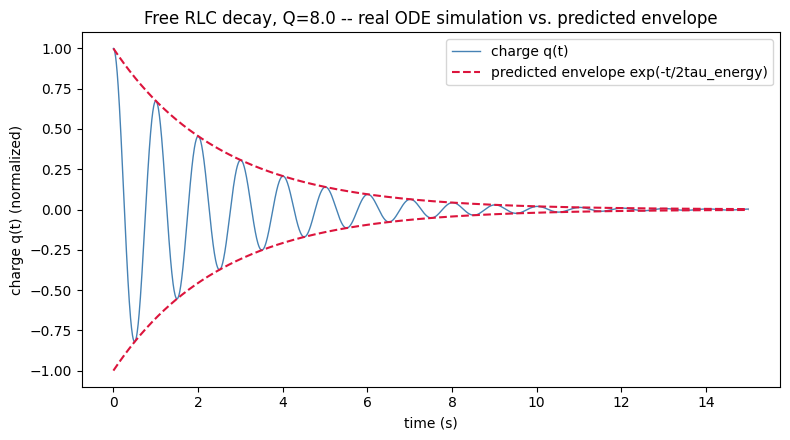

In [8]:
# a LOWER-Q demo (visibly decaying within a plottable number of cycles)
rlc_plot = lca.rlc_equivalent_from_Q(f0=1.0, Q=8.0, R=50.0)
omega0_plot = rlc_plot['omega0_rad_s']

def rhs(t, y):
    q, i = y
    return [i, (-rlc_plot['R_ohm']*i - q/rlc_plot['C_F'])/rlc_plot['L_H']]

from scipy.integrate import solve_ivp
t_span = (0.0, 15*2*np.pi/omega0_plot)
t_eval = np.linspace(*t_span, 2000)
sol = solve_ivp(rhs, t_span, y0=[1.0, 0.0], t_eval=t_eval, rtol=1e-10, atol=1e-14)

tau_energy = rlc_plot['L_H']/rlc_plot['R_ohm']
envelope = np.exp(-t_eval/(2*tau_energy))   # amplitude envelope: tau_amplitude = 2*tau_energy

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(t_eval, sol.y[0], color='steelblue', lw=1, label='charge q(t)')
ax.plot(t_eval, envelope, color='crimson', ls='--', lw=1.5, label='predicted envelope exp(-t/2tau_energy)')
ax.plot(t_eval, -envelope, color='crimson', ls='--', lw=1.5)
ax.set_xlabel('time (s)'); ax.set_ylabel('charge q(t) (normalized)')
ax.set_title(f'Free RLC decay, Q={8.0} -- real ODE simulation vs. predicted envelope')
ax.legend()
plt.tight_layout()
plt.savefig('laser_rlc_ode_decay.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. Laser Threshold, Derived: Gain = Loss $\Leftrightarrow$ Net Resistance = 0

**Step 1 -- round-trip gain.** A gain medium of coefficient $g$ (per unit
length) amplifies intensity as $e^{gz}$ over a length $z$; over one full
round trip (length $2L$, gain applied on BOTH passes) the intensity is
multiplied by $e^{2gL}$.

**Step 2 -- round-trip survival.** Section 1's loss factor
$R_{rt}=R_1R_2e^{-2\alpha L}$ (mirrors + absorption) multiplies the SAME
round trip.

**Step 3 -- threshold condition.** Steady-state lasing requires the
round trip to reproduce the SAME intensity it started with -- gain and
loss exactly cancel:
$$e^{2gL}\cdot R_1R_2e^{-2\alpha L}=1.$$
Solved for $g$ below via SymPy (not quoted), giving
$g_{th}=\alpha-\frac{\ln(R_1R_2)}{2L}=\alpha+\frac{1}{2L}\ln\frac{1}{R_1R_2}$
-- confirming the module's closed form is the actual solution of the
threshold equation, not a plausible-looking formula with the right units.


In [9]:
g_sym, alpha_sym, L_sym, R1_sym, R2_sym = sp.symbols('g alpha L R_1 R_2', positive=True)
round_trip_condition = sp.Eq(sp.exp(2*g_sym*L_sym) * R1_sym*R2_sym*sp.exp(-2*alpha_sym*L_sym), 1)
print('round-trip condition:', round_trip_condition)

g_th_derived = sp.solve(round_trip_condition, g_sym)[0]
print('g_th (derived) =', g_th_derived)

g_th_numeric_from_formula = float(g_th_derived.subs({alpha_sym: alpha, L_sym: L, R1_sym: R1, R2_sym: R2}))
g_th_module = lca.laser_threshold_gain(R1, R2, alpha, L)
print(f'\ng_th: derived formula={g_th_numeric_from_formula:.6f} /m   module={g_th_module:.6f} /m'
      f'   match: {abs(g_th_numeric_from_formula-g_th_module)<1e-9}')


round-trip condition: Eq(R_1*R_2*exp(-2*L*alpha)*exp(2*L*g), 1)
g_th (derived) = alpha - log(R_1*R_2)/(2*L)

g_th: derived formula=0.033671 /m   module=0.033671 /m   match: True


In [10]:
g_th = lca.laser_threshold_gain(R1, R2, alpha, L)
ok = lca.verify_threshold_condition(R1, R2, alpha, L)
print(f'threshold gain g_th = {g_th:.4f} /m')
print(f'round-trip gain*loss at threshold = 1, verified: {ok}')

R_loss = rlc['R_ohm']
analog = lca.electrical_threshold_analog(R_loss)
print(f"\nelectrical analog: R_loss={analog['R_loss_ohm']:.1f} ohm + R_gain={analog['R_gain_ohm']:.1f} ohm "
      f"= net R={analog['net_R_ohm']:.1f} ohm  (at threshold: {analog['at_threshold']})")


threshold gain g_th = 0.0337 /m
round-trip gain*loss at threshold = 1, verified: True

electrical analog: R_loss=50.0 ohm + R_gain=-50.0 ohm = net R=0.0 ohm  (at threshold: True)


## 5. Engineering Interpretation

- Section 1's derivation matters because $T_{rt}=2nL/c$ is usually
  memorized, not derived -- tracing it to retarded time makes clear WHY
  it's exact (finite propagation speed, applied twice) rather than a
  cavity-specific rule.
- Section 2's approximation-breakdown plot is the same discipline as
  `dgs/cylindrical_waveguide_resonance.py`'s resonance-peak-shift finding:
  two textbook formulas that "obviously" agree do so only in a specific
  limit, shown quantitatively rather than assumed.
- Section 3's frequency-scale workaround (verify the METHOD at a tractable
  frequency, not the literal optical-frequency circuit) is a real
  numerical-feasibility lesson: some physics claims are true at ANY scale
  algebraically but need care to verify computationally at the scale they
  actually occur.


## 6. Research Discussion

- Section 1's retarded-time derivation used a 1D scalar wave equation.
  Could the FULL vector retarded-potential integral (Step 3's
  $V(\mathbf r,t)$) be evaluated in SymPy for a specific oscillating
  dipole source, connecting this notebook to a genuine Griffiths ch. 11
  radiation calculation rather than just quoting the formula?
- `dgs/pierce_oscillator.py` already models a crystal's motional
  resonance electrically. Could ITS negative-resistance oscillator startup
  condition be compared numerically against this notebook's
  `electrical_threshold_analog`, to see if they're the SAME condition
  stated two ways or genuinely different circuit topologies?
- Could the retarded-time derivation in section 1 be extended to a cavity
  with a MOVING mirror (e.g. modeling mirror vibration/microphonics),
  connecting it to Doppler-shift physics via the same retarded-time
  framework rather than a separate derivation?


## 7. Possible Experiments

1. Measure a real HeNe or diode laser's actual linewidth (via a scanning
   Fabry-Perot or beat-note measurement) and compare against BOTH
   `linewidth_from_Q` and `linewidth_from_finesse` for that laser's known
   mirror reflectivities -- confirm which formula the real measurement
   tracks more closely.
2. Build a physical RLC circuit with `rlc_equivalent_from_Q`'s component
   values (scaled to an audio-frequency demo, matching section 3's
   1 MHz-or-lower approach) and measure its ring-down time on an
   oscilloscope, comparing against the predicted $\tau_{energy}=L/R$.
3. Extend section 1's SymPy wave-equation check to 2D or 3D (verify
   $f(t-\hat n\cdot\mathbf r/v)$ solves the multidimensional wave
   equation for a plane wave in direction $\hat n$), connecting to
   `dgs/em_lagrangian_action.py`'s plane-wave verification.


## 8. Problems to Solve: RLC and Laser Threshold

Section 4 stopped at threshold ($net\ R=0$). Pushing past it, and into
the RLC formalism's other unexplored regimes:

1. **Above threshold: sustained growth.** `electrical_threshold_analog`
   only checks $R_{gain}=-R_{loss}$ exactly. Extend it (or write a small
   variant) for $|R_{gain}|>R_{loss}$ (net $R<0$) and re-run
   `verify_rlc_matches_cavity_decay`'s ODE integration with that negative
   net resistance -- confirm the charge amplitude now GROWS
   exponentially ($\tau_{energy}<0$ in the L/R formula), the electrical
   mirror of a laser's power building up above threshold.

2. **Relaxation oscillations.** Real lasers don't jump straight to
   steady output above threshold -- gain and photon number are COUPLED,
   producing a damped ringing transient (relaxation oscillations) before
   settling. Model this as a 2-variable rate-equation system (photon
   number, gain saturation) and compare its ringing frequency/damping to
   a driven RLC circuit's own transient response from
   `verify_rlc_matches_cavity_decay`'s ODE.

3. **Which longitudinal mode lases first?** `dgs/cylindrical_waveguide_resonance.py`
   already computes cavity mode spacing (FSR-equivalent). If gain is
   frequency-dependent (a gain spectrum peaked at one wavelength), combine
   `laser_threshold_gain` with a cavity's mode comb to find which specific
   longitudinal mode reaches threshold FIRST as pump power increases.

4. **Q-switching as a time-varying resistance.** Model a Q-switch (a
   sudden loss reduction, e.g. from a shutter opening) as $R_{loss}(t)$
   abruptly stepping down mid-simulation in the free-RLC ODE -- does the
   resulting transient reproduce a Q-switched laser's characteristic giant
   pulse shape?

5. **A buildable negative-resistance circuit.** `electrical_threshold_analog`
   treats $R_{gain}=-R_{loss}$ as ideal and abstract. Design an actual
   op-amp-based negative-impedance converter (NIC) circuit that would
   physically realize a negative resistance at the values this module
   computes, and verify (via `dgs/ac_circuits.py`'s impedance primitives)
   that its impedance really does look like $-R_{loss}$ over a useful
   frequency range.


## 9. Future Improvements

- Section 1 stopped at the 1D scalar wave equation for algebraic clarity.
  A from-scratch derivation of the retarded potentials themselves (solving
  the inhomogeneous wave equation $\nabla^2V-\frac{1}{c^2}\ddot V=
  -\rho/\varepsilon_0$ via Green's functions) would close the gap between
  "verified for f(t-x/v)" and "Griffiths' actual retarded-potential
  formula," at the cost of a much longer derivation.
- `verify_rlc_matches_cavity_decay`'s peak-finding fit (section 3) uses a
  simple local-maximum detector; for a very low-Q, heavily-damped case it
  could misidentify peaks -- a proper Hilbert-transform envelope
  extraction would be more robust across the full Q range.
